## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [50]:
%reload_ext autoreload
%autoreload 2


In [51]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage


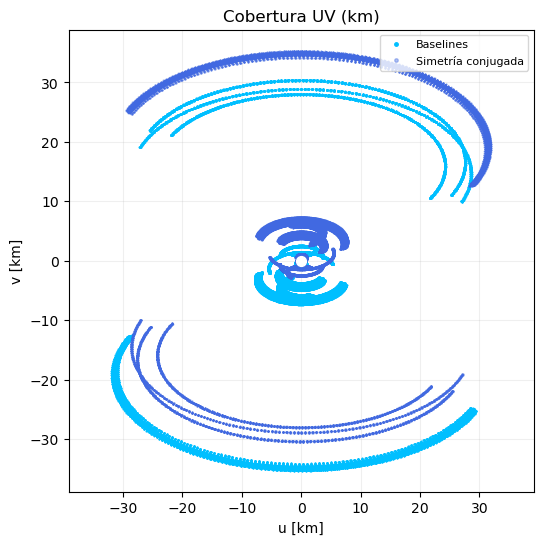

In [60]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/ska_low_AA2.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T00:00:00",
    "utc_end": "2023-11-21T12:00:00",
    "step_min": 5,
    "n_freqs": 100,
    'bandwidth': 1e06, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 10,
    "max_offset_deg": 1, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ = visibilities_simulation(SKA_LOW_AA1)

plot_uv_coverage(uvw, unit='km')

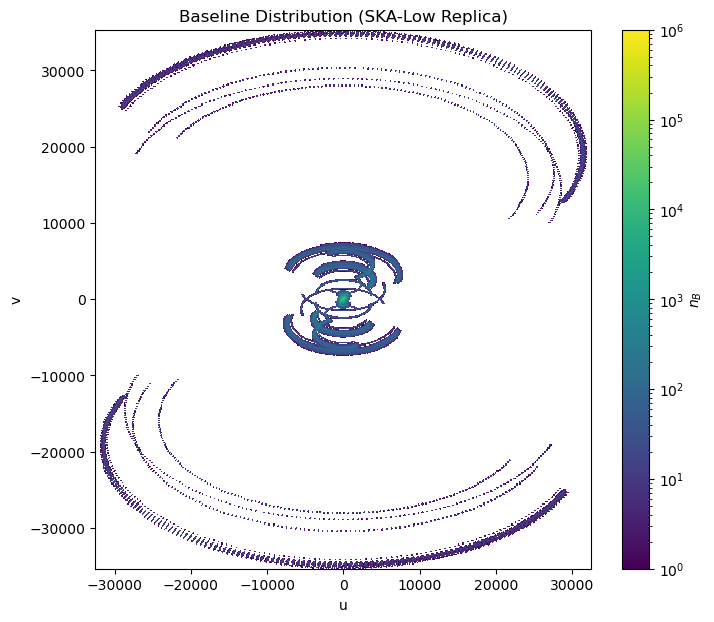

In [61]:
def plot_uv_density_paper_style(uvw, bins=512):
    # Extraemos u y v (asegúrate de que estén en las unidades deseadas, ej. baselines)
    u = uvw[..., 0].flatten()
    v = uvw[..., 1].flatten()
    
    # El paper asume simetría conjugada completa
    u_full = np.concatenate([u, -u])
    v_full = np.concatenate([v, -v])
    
    plt.figure(figsize=(8, 7))
    
    # Histograma 2D con escala logarítmica para n_B
    # El rango debe coincidir con la extensión de tus baselines (ej. -250 a 250)
    h = plt.hist2d(u_full, v_full, bins=bins, 
                   cmap='viridis', # O 'YlGnBu_r' para un look similar
                   norm=colors.LogNorm(vmin=1, vmax=1e6)) # Rango 10^0 a 10^6 como el paper
    
    plt.colorbar(label='$n_B$')
    plt.xlabel('u')
    plt.ylabel('v')
    plt.title('Baseline Distribution (SKA-Low Replica)')
    plt.axis('equal')
    plt.show()

plot_uv_density_paper_style(uvw, 512)

In [62]:
print("uvw shape: ", uvw.shape)
print("V shape: ", V.shape)
print("V baselines shape: ", V[0].shape)
print("Primeros 5 registros del baseline 0: \n", V[0][:5])   

uvw shape:  (2016, 145, 3)
V shape:  (2016, 145, 100)
V baselines shape:  (145, 100)
Primeros 5 registros del baseline 0: 
 [[ 4.1403947 -3.8712575j  4.069029  -3.8851779j  3.997601  -3.8988857j
   3.9261184 -3.9123788j  3.8545873 -3.925658j   3.783014  -3.938721j
   3.7114058 -3.9515686j  3.6397688 -3.9641993j  3.56811   -3.9766126j
   3.4964354 -3.9888074j  3.4247522 -4.000784j   3.353067  -4.0125413j
   3.2813852 -4.024078j   3.2097147 -4.0353937j  3.1380615 -4.0464892j
   3.0664322 -4.057362j   2.9948335 -4.0680127j  2.9232714 -4.07844j
   2.851753  -4.0886445j  2.7802844 -4.0986238j  2.708872  -4.108379j
   2.637523  -4.1179085j  2.566243  -4.1272125j  2.4950385 -4.1362906j
   2.4239163 -4.1451416j  2.3528826 -4.1537657j  2.281944  -4.162162j
   2.2111065 -4.1703296j  2.1403766 -4.17827j    2.0697606 -4.18598j
   1.999265  -4.193462j   1.9288958 -4.2007127j  1.8586593 -4.2077346j
   1.7885619 -4.214525j   1.7186097 -4.2210846j  1.6488088 -4.227412j
   1.5791655 -4.233509j   1.5096

In [63]:
from modules.noise import narrowband_rfi

V_rfi, k, f_rfi = narrowband_rfi(
    V,
    frequencies,
    amplitude=10,
    k_rfi=7,
    seed=42
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted = V + V_rfi

Canal RFI: 7
Frecuencia [MHz]: 157.5


In [64]:
def plot_visibility_waterfall_publication(
    V,
    frequencies,
    eps=1e-6,
    figsize=(10, 6),
    title_suffix=""
):
    """
    Publication-style waterfall plot (time vs frequency)
    matching standard radio astronomy figures.
    """

    frequencies = np.asarray(frequencies)

    # Average over baselines
    V_tf = np.mean(V, axis=0)  # (time, freq)

    # --- Amplitude ---
    amp = np.abs(V_tf)
    amp_log = np.log10(amp / np.median(amp) + eps)

    vmin = np.percentile(amp_log, 5)
    vmax = np.percentile(amp_log, 99.5)

    # --- Phase ---
    phase = np.angle(V_tf)

    extent = [
        frequencies.min() / 1e6,
        frequencies.max() / 1e6,
        0,
        amp_log.shape[0]
    ]

    fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True)

    im0 = axs[0].imshow(
        amp_log,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        extent=extent
    )
    axs[0].set_ylabel("Time Integrations")
    axs[0].set_title(f"Amplitude (log scale) {title_suffix}")
    plt.colorbar(im0, ax=axs[0], label="log₁₀(|V| / median)")

    im1 = axs[1].imshow(
        phase,
        aspect="auto",
        origin="lower",
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi,
        extent=extent
    )
    axs[1].set_xlabel("Frequency [MHz]")
    axs[1].set_ylabel("Time Integrations")
    axs[1].set_title(f"Phase {title_suffix}")
    plt.colorbar(im1, ax=axs[1], label="Phase [rad]")

    plt.tight_layout()
    plt.show()


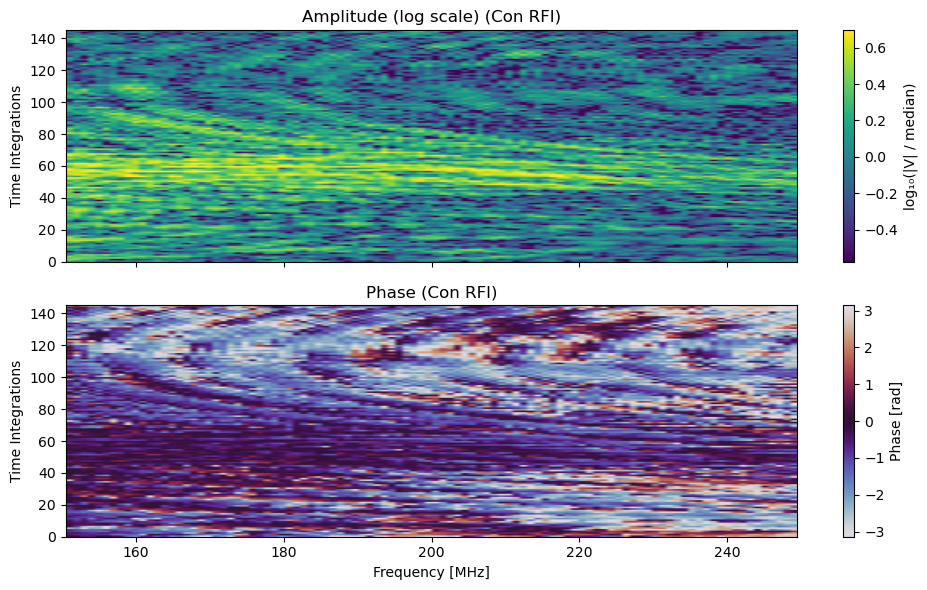

In [65]:
plot_visibility_waterfall_publication(
    V,
    frequencies,
    title_suffix="(Con RFI)"
)


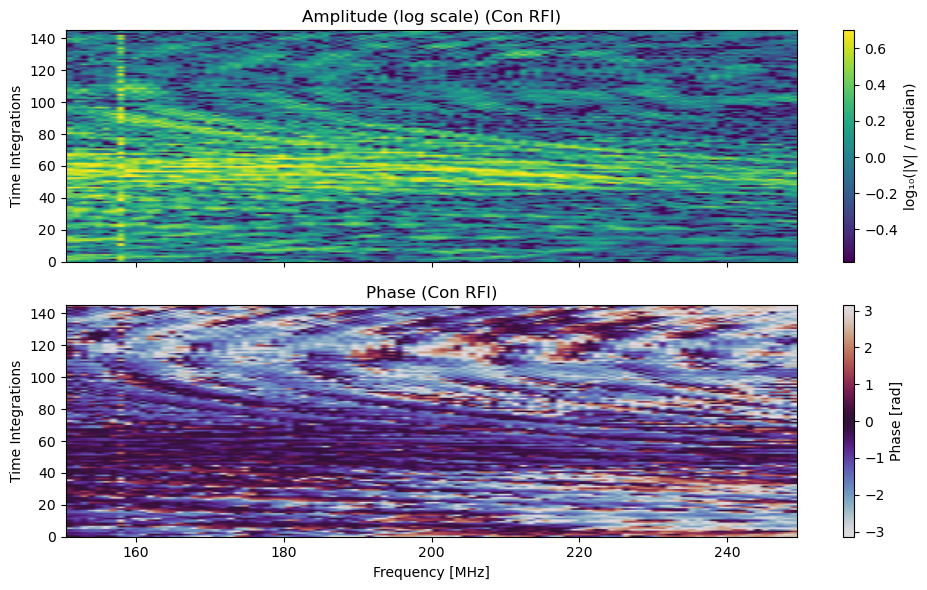

In [66]:
plot_visibility_waterfall_publication(
    V_corrupted,
    frequencies,
    title_suffix="(Con RFI)"
)
